# Flower Classifier — Predict Using Saved Model
### Uses the best model: PyTorch ResNet50 (90.19% accuracy)

Upload any flower image and the model will predict whether it's a **Daisy, Dandelion, Rose, Sunflower, or Tulip** with confidence scores.


In [4]:
# Cell 1: Install required packages
!pip install torch torchvision opencv-python-headless matplotlib --quiet


In [5]:
# Cell 2: Import libraries
import torch
import torch.nn as nn
import torchvision.models as models
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


Libraries loaded successfully!
PyTorch version: 2.10.0+cu128
Device: cuda


In [6]:
# Cell 3: Load model from Google Drive (faster + more reliable than upload)
from google.colab import drive
drive.mount('/content/drive')

# Change this path to wherever you saved the file in your Drive
model_path = '/content/drive/MyDrive/pt_resnet50_flowers.pth'

import os
if os.path.exists(model_path):
    print(f"Model found: {model_path}")
    print(f"File size: {os.path.getsize(model_path) / 1e6:.1f} MB")
else:
    print("File not found! Check the path above.")
    print("Upload the .pth file to your Google Drive first, then update the path.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model found: /content/drive/MyDrive/pt_resnet50_flowers.pth
File size: 99.1 MB


In [7]:
# Cell 4: Rebuild the model architecture and load weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 150
CLASS_NAMES = ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip']

# Rebuild the exact same architecture used during training
model = models.resnet50(weights=None)  # no pretrained weights — we'll load our own

# Freeze/unfreeze pattern must match training
for name, param in model.named_parameters():
    param.requires_grad = True if ('layer4' in name or 'fc' in name) else False

# Replace FC layer with the same custom classifier
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.BatchNorm1d(num_features),
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.BatchNorm1d(512),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 5)
)

# Load the trained weights
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully!")
print(f"Running on: {device}")
print(f"Classes: {CLASS_NAMES}")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}")


Model loaded successfully!
Running on: cuda
Classes: ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip']
Input size: 150x150


In [8]:
# Cell 5: Define prediction function
def predict_flower(image_path):
    """Predict flower class from an image file path."""

    # Read and preprocess the image
    img_original = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img_original is None:
        print(f"Error: Could not read image {image_path}")
        return

    img_resized = cv2.resize(img_original, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    # Normalize to [0, 1] and convert to channels-first tensor
    img_tensor = img_resized.astype(np.float32) / 255.0
    img_tensor = torch.FloatTensor(img_tensor.transpose(2, 0, 1))  # (C, H, W)
    img_tensor = img_tensor.unsqueeze(0).to(device)  # (1, C, H, W)

    # Predict
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        predicted_class = np.argmax(probabilities)
        confidence = probabilities[predicted_class] * 100

    # ---- Visualization ----
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Show the image with prediction
    img_display = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    ax1.imshow(img_display)
    color = '#2E7D32' if confidence > 70 else '#F57F17' if confidence > 50 else '#C62828'
    ax1.set_title(f'Predicted: {CLASS_NAMES[predicted_class]}\nConfidence: {confidence:.1f}%',
                   fontsize=16, fontweight='bold', color=color)
    ax1.axis('off')

    # Right: Confidence bar chart for all classes
    bar_colors = ['#E8F5E9'] * 5
    bar_colors[predicted_class] = '#2E7D32'

    bars = ax2.barh(CLASS_NAMES, probabilities * 100, color=bar_colors,
                     edgecolor=['#2E7D32' if i == predicted_class else '#BDBDBD'
                                for i in range(5)],
                     linewidth=2)

    for i, (bar, prob) in enumerate(zip(bars, probabilities * 100)):
        if prob > 2:
            ax2.text(prob + 1, bar.get_y() + bar.get_height()/2,
                     f'{prob:.1f}%', va='center', fontsize=12,
                     fontweight='bold' if i == predicted_class else 'normal')

    ax2.set_xlim(0, 110)
    ax2.set_xlabel('Confidence (%)', fontsize=13)
    ax2.set_title('Prediction Confidence per Class', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n{'='*50}")
    print(f"  Prediction: {CLASS_NAMES[predicted_class]}")
    print(f"  Confidence: {confidence:.2f}%")
    print(f"{'='*50}")
    print(f"\nAll class probabilities:")
    for i, (name, prob) in enumerate(zip(CLASS_NAMES, probabilities)):
        marker = "  <<<" if i == predicted_class else ""
        print(f"  {name:12s}: {prob*100:6.2f}%{marker}")

    return CLASS_NAMES[predicted_class], confidence

print("Prediction function ready!")


Prediction function ready!


---
## Upload a Flower Image to Classify
Run the cell below, then upload any flower image (jpg, png, etc.)


Upload a flower image to classify:
(Supported: jpg, jpeg, png, bmp, webp)



Saving summer-flowers-sunflower-1648478429.jpg.avif to summer-flowers-sunflower-1648478429.jpg.avif

Processing: summer-flowers-sunflower-1648478429.jpg.avif
--------------------------------------------------


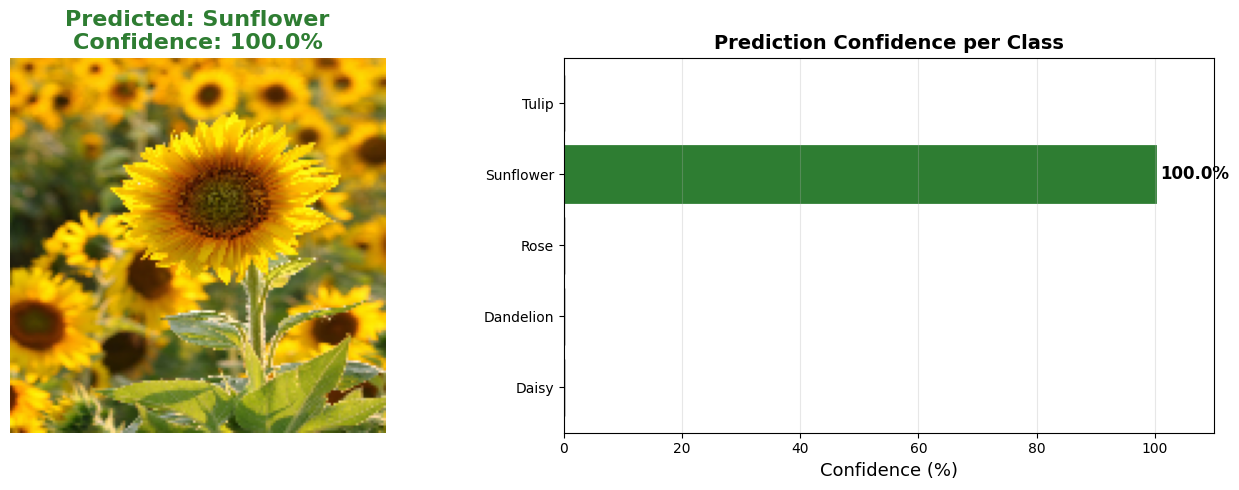


  Prediction: Sunflower
  Confidence: 99.98%

All class probabilities:
  Daisy       :   0.01%
  Dandelion   :   0.00%
  Rose        :   0.00%
  Sunflower   :  99.98%  <<<
  Tulip       :   0.01%


In [9]:
# Cell 6: Upload and predict — SINGLE IMAGE
print("Upload a flower image to classify:")
print("(Supported: jpg, jpeg, png, bmp, webp)")
print()

uploaded_images = files.upload()

for filename in uploaded_images.keys():
    print(f"\nProcessing: {filename}")
    print("-" * 50)
    prediction, confidence = predict_flower(filename)


---
## Predict Multiple Images at Once
Upload several flower images and see all predictions


Upload multiple flower images:



Saving photo-1770650776137-d9e749697fc4.avif to photo-1770650776137-d9e749697fc4 (1).avif
Saving shopping.jpeg to shopping.jpeg
Saving SPRARE.jpg to SPRARE (1).jpg
Saving summer-flowers-sunflower-1648478429.jpg.avif to summer-flowers-sunflower-1648478429.jpg (2).avif

  Image: photo-1770650776137-d9e749697fc4 (1).avif


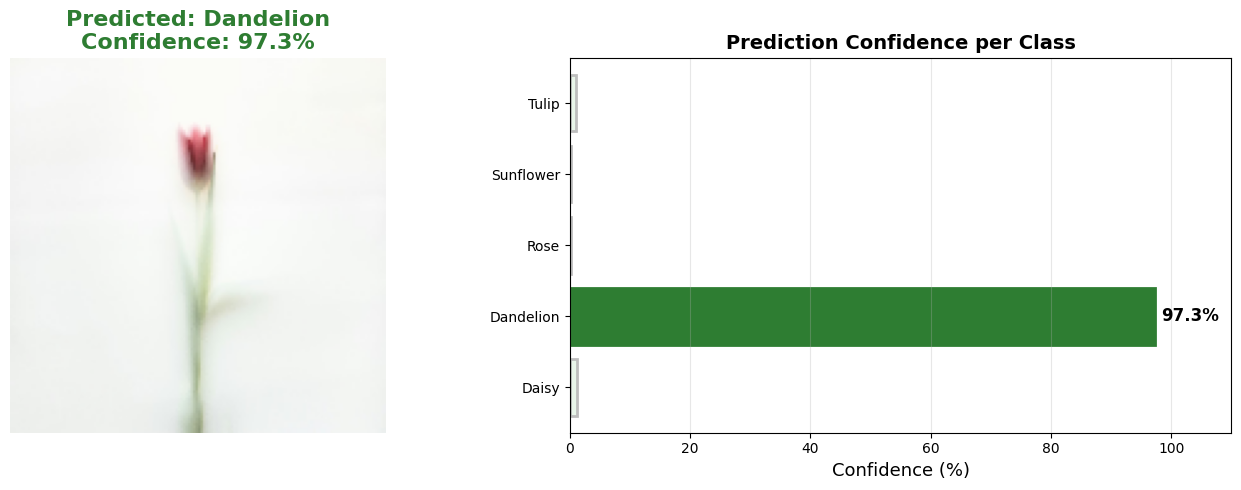


  Prediction: Dandelion
  Confidence: 97.28%

All class probabilities:
  Daisy       :   1.30%
  Dandelion   :  97.28%  <<<
  Rose        :   0.21%
  Sunflower   :   0.22%
  Tulip       :   0.98%

  Image: shopping.jpeg


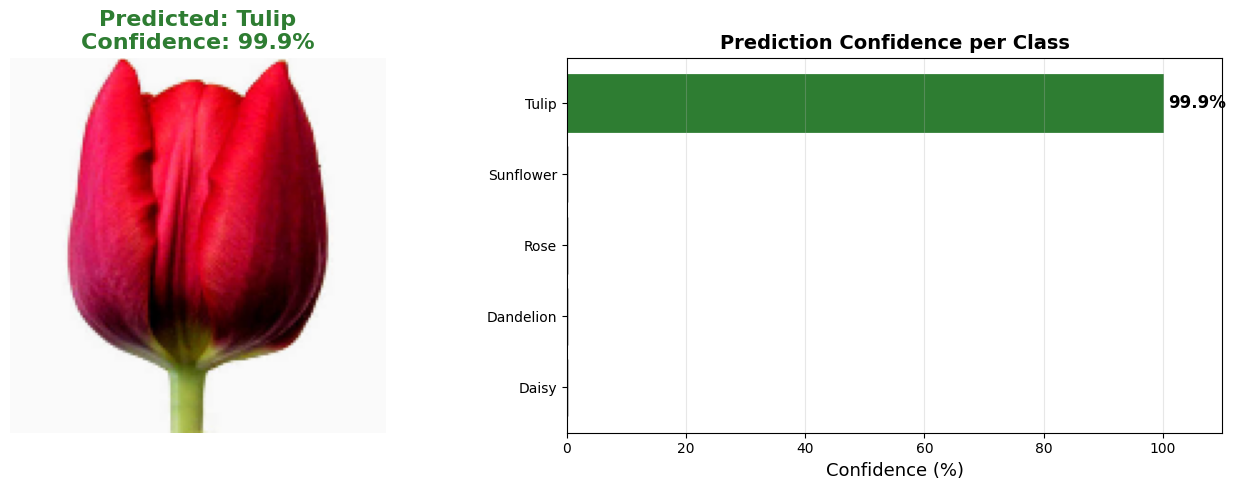


  Prediction: Tulip
  Confidence: 99.93%

All class probabilities:
  Daisy       :   0.01%
  Dandelion   :   0.01%
  Rose        :   0.03%
  Sunflower   :   0.01%
  Tulip       :  99.93%  <<<

  Image: SPRARE (1).jpg


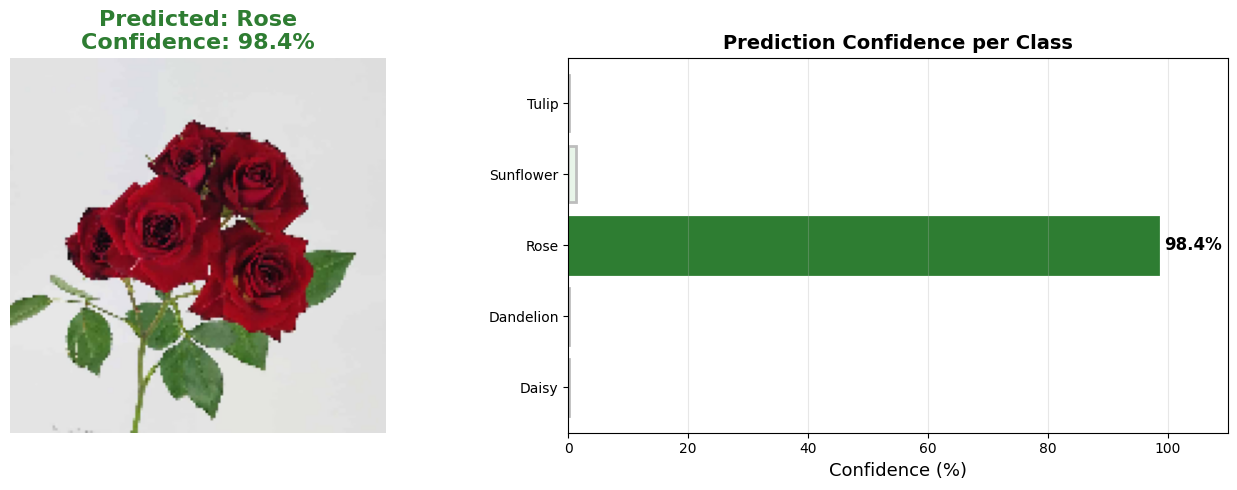


  Prediction: Rose
  Confidence: 98.43%

All class probabilities:
  Daisy       :   0.12%
  Dandelion   :   0.09%
  Rose        :  98.43%  <<<
  Sunflower   :   1.27%
  Tulip       :   0.08%

  Image: summer-flowers-sunflower-1648478429.jpg (2).avif


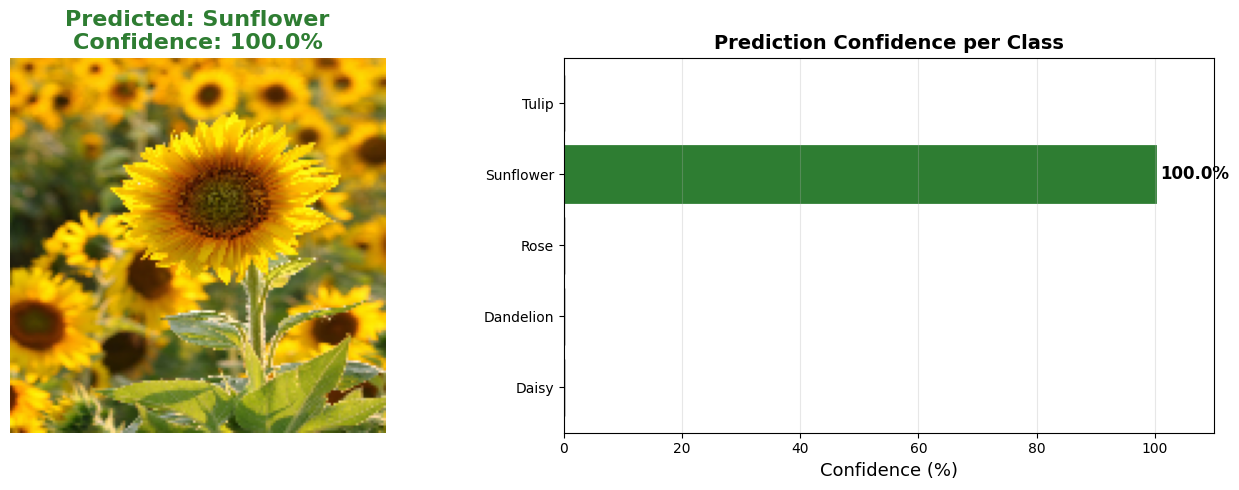


  Prediction: Sunflower
  Confidence: 99.98%

All class probabilities:
  Daisy       :   0.01%
  Dandelion   :   0.00%
  Rose        :   0.00%
  Sunflower   :  99.98%  <<<
  Tulip       :   0.01%


  SUMMARY OF ALL PREDICTIONS
Image                          Prediction      Confidence
------------------------------------------------------------
photo-1770650776137-d9e749697fc4 (1).avif Dandelion           97.28%
shopping.jpeg                  Tulip               99.93%
SPRARE (1).jpg                 Rose                98.43%
summer-flowers-sunflower-1648478429.jpg (2).avif Sunflower           99.98%


In [11]:
# Cell 7: Upload and predict — MULTIPLE IMAGES
print("Upload multiple flower images:")
print()

uploaded_images = files.upload()
results = []

for filename in uploaded_images.keys():
    print(f"\n{'='*60}")
    print(f"  Image: {filename}")
    print(f"{'='*60}")
    prediction, confidence = predict_flower(filename)
    results.append({'filename': filename, 'prediction': prediction, 'confidence': confidence})

# Summary table
print("\n\n" + "=" * 60)
print("  SUMMARY OF ALL PREDICTIONS")
print("=" * 60)
print(f"{'Image':<30s} {'Prediction':<15s} {'Confidence':>10s}")
print("-" * 60)
for r in results:
    print(f"{r['filename']:<30s} {r['prediction']:<15s} {r['confidence']:>9.2f}%")
print("=" * 60)


---
## Test with Random Images from the Dataset
If you still have the dataset downloaded, test with random images from it


Using Colab cache for faster access to the 'flowers-recognition' dataset.


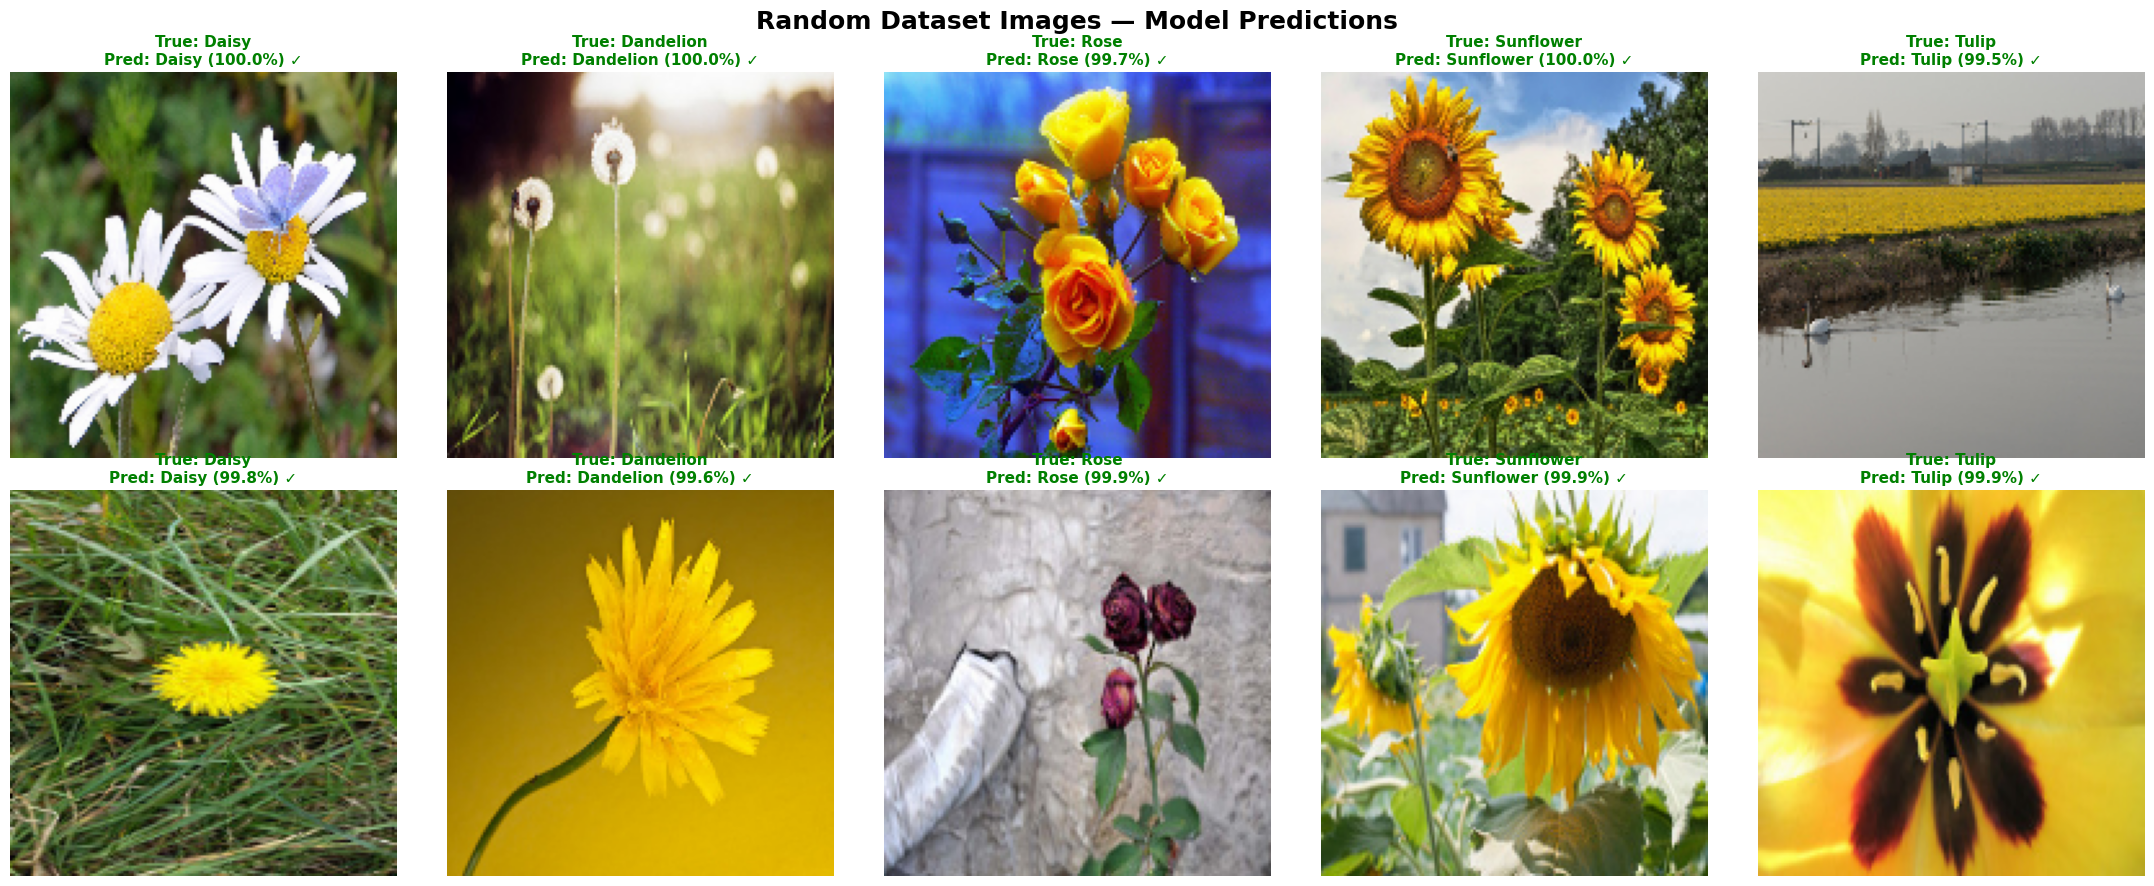


Quick test accuracy: 10/10 = 100.0%


In [12]:
# Cell 9: Test with random dataset images (optional — needs dataset)
import os
import random

try:
    import kagglehub
    path = kagglehub.dataset_download("alxmamaev/flowers-recognition")
    base_dir = os.path.join(path, 'flowers')
    if os.path.exists(os.path.join(base_dir, 'flowers')):
        base_dir = os.path.join(base_dir, 'flowers')

    # Pick 2 random images from each class
    fig, axes = plt.subplots(2, 5, figsize=(22, 9))
    fig.suptitle('Random Dataset Images — Model Predictions', fontsize=18, fontweight='bold')

    class_dirs = {'Daisy': 'daisy', 'Dandelion': 'dandelion', 'Rose': 'rose',
                  'Sunflower': 'sunflower', 'Tulip': 'tulip'}

    all_correct = 0
    all_total = 0

    for col, (class_name, dir_name) in enumerate(class_dirs.items()):
        class_dir = os.path.join(base_dir, dir_name)
        images = os.listdir(class_dir)
        random.seed(42)
        sample_imgs = random.sample(images, 2)

        for row, img_name in enumerate(sample_imgs):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is None:
                continue

            img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

            # Predict
            img_tensor = img_resized.astype(np.float32) / 255.0
            img_tensor = torch.FloatTensor(img_tensor.transpose(2, 0, 1)).unsqueeze(0).to(device)

            with torch.no_grad():
                outputs = model(img_tensor)
                probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
                pred_idx = np.argmax(probs)
                conf = probs[pred_idx] * 100

            pred_name = CLASS_NAMES[pred_idx]
            is_correct = pred_name == class_name
            all_total += 1
            all_correct += int(is_correct)

            axes[row, col].imshow(img_rgb)
            color = 'green' if is_correct else 'red'
            symbol = '\u2713' if is_correct else '\u2717'
            axes[row, col].set_title(f'True: {class_name}\nPred: {pred_name} ({conf:.1f}%) {symbol}',
                                      fontsize=11, fontweight='bold', color=color)
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\nQuick test accuracy: {all_correct}/{all_total} = {all_correct/all_total*100:.1f}%")

except Exception as e:
    print(f"Dataset not available: {e}")
    print("This cell is optional — use Cells 6, 7, or 8 to predict on your own images.")


---
## How to Use This Notebook

1. **Upload the model file** (Cell 3) — upload `pt_resnet50_flowers.pth` that you saved from training
2. **Model loads automatically** (Cell 4) — rebuilds the architecture and loads your trained weights
3. **Predict on images** using any of these methods:
   - **Cell 6:** Upload a single image from your computer
   - **Cell 7:** Upload multiple images at once and see all predictions
   - **Cell 8:** Paste an image URL from the internet
   - **Cell 9:** Test on random images from the Kaggle dataset

The model classifies flowers into 5 classes: **Daisy, Dandelion, Rose, Sunflower, Tulip**
